In [ ]:
# DBSCAN Clustering Algorithm
# DBSCAN - Density-Based Spatial Clustering of Application with Noise

In [4]:
# 1. minpoint = 4
# 2. epn(r) = 0.5

# a. core point    - No point >= minpoint
# b. binary point  - No point < minpoint
# c. noise point   - outlier

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

In [6]:
dataset = pd.read_csv("unlabel_Iris.csv")
dataset.head(3)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [7]:
x, y = make_moons(n_samples=250, noise=0.05)

In [9]:
x

array([[ 1.13126582, -0.52806668],
       [-0.93822083, -0.08627845],
       [ 1.24815929, -0.43830194],
       [ 0.58852818,  0.79132594],
       [ 1.43194614, -0.40570755],
       [ 0.03042109, -0.02858992],
       [-0.97969268,  0.01292038],
       [-0.59571581,  0.86592708],
       [-0.51298218,  0.80115087],
       [ 0.24402804,  0.94573052],
       [ 0.07411889,  0.3245366 ],
       [ 0.41866474,  0.89685794],
       [ 1.89642123,  0.16937508],
       [ 0.07930355,  0.09852963],
       [ 0.8253612 ,  0.52541091],
       [ 0.76213205,  0.7507333 ],
       [ 0.38086666,  0.98323443],
       [ 0.43702488, -0.29809958],
       [ 0.37977279,  0.88034411],
       [-0.27118825,  0.93625926],
       [ 1.95986565,  0.16108145],
       [ 0.04652712,  1.01908657],
       [-1.02758517,  0.12012648],
       [-0.66755091,  0.7067025 ],
       [-0.06339731,  0.93238603],
       [ 0.87061987,  0.46771138],
       [ 0.28961488,  0.9572507 ],
       [-0.1077103 ,  0.98664456],
       [-0.99193997,

In [8]:
y

array([1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1])

In [13]:
df = {"data1":x[:,0] , "data2":x[:, 1], "output":y}

In [11]:
x[:, 0]

array([ 1.13126582, -0.93822083,  1.24815929,  0.58852818,  1.43194614,
        0.03042109, -0.97969268, -0.59571581, -0.51298218,  0.24402804,
        0.07411889,  0.41866474,  1.89642123,  0.07930355,  0.8253612 ,
        0.76213205,  0.38086666,  0.43702488,  0.37977279, -0.27118825,
        1.95986565,  0.04652712, -1.02758517, -0.66755091, -0.06339731,
        0.87061987,  0.28961488, -0.1077103 , -0.99193997,  0.68263757,
        0.71057331,  1.84657357,  0.12535154, -1.0449122 , -0.73674081,
        0.75585359,  0.21220901, -0.44725471,  0.98430954,  0.81438285,
        0.20803139,  1.89221923, -0.86993316, -0.97874042, -0.93393466,
       -0.11384165,  1.68931038, -0.73849187,  0.33741873,  0.92887037,
        0.7822888 , -0.85423839,  1.84057253,  0.56827652,  0.08717211,
       -0.92079648,  1.98214625,  1.16190193, -0.70226202,  0.9461475 ,
        1.29211407,  1.23431739, -0.34344804,  2.05262199, -0.1601403 ,
       -0.38704428, -0.8292201 ,  0.65296838,  0.04922951, -0.70

In [15]:
dataset = pd.DataFrame(df)

In [16]:
dataset.head(3)

,data1,data2,output
0,1.131266,-0.528067,1
1,-0.938221,-0.086278,0
2,1.248159,-0.438302,1


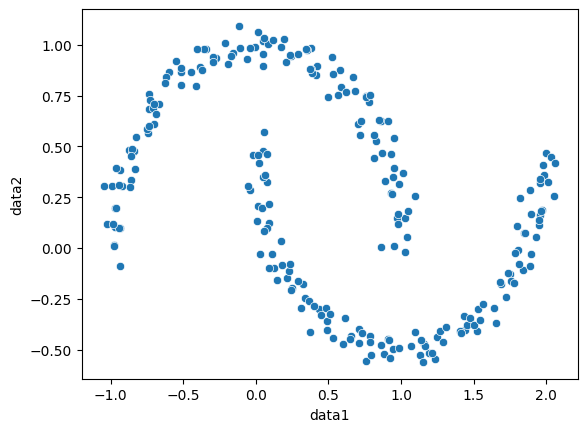

In [17]:
sns.scatterplot(x="data1", y="data2", data=dataset)
plt.show()

In [18]:
from sklearn.cluster import DBSCAN

In [22]:
db = DBSCAN(eps=0.2, min_samples=5)
dataset["Predict"] = db.fit_predict(dataset)

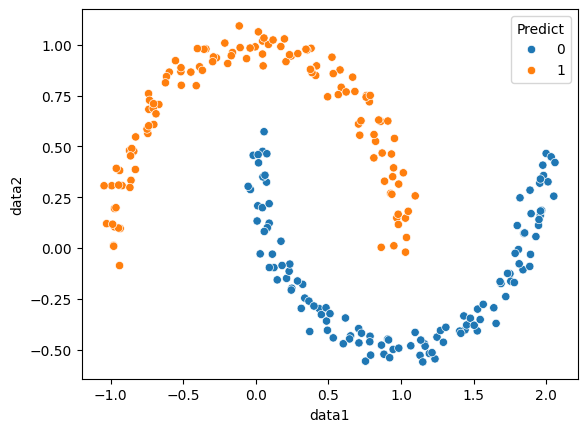

In [23]:
sns.scatterplot(x="data1", y="data2", data=dataset, hue="Predict")
plt.show()

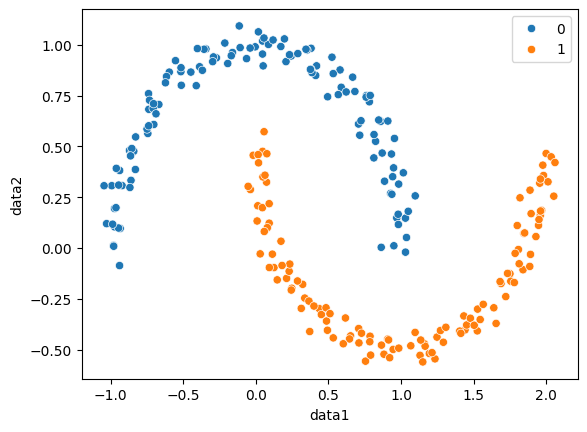

In [24]:
sns.scatterplot(x="data1", y="data2", data=dataset, hue=y)
plt.show()